In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, clear_output
import time

In [3]:
def discretize(obs, bins):
    return tuple(
        np.digitize(obs[i], bins[i])
        for i in range(len(obs))
    )

def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(3)
    return np.argmax(Q[state])

In [4]:
def make_bins(num_bins):
    bins = []

    # cos and sin ∈ [-1,1]
    for _ in range(4):
        bins.append(np.linspace(-1, 1, num_bins - 1))

    # velocities (use env limits)
    bins.append(np.linspace(-4*np.pi, 4*np.pi, num_bins - 1))
    bins.append(np.linspace(-9*np.pi, 9*np.pi, num_bins - 1))
    return bins

In [21]:
def plot_returns(returns, alpha=0.1):
    plt.figure()
    returns = np.array(returns)

    # Plot raw returns with transparency
    plt.plot(returns, alpha=0.3, label='Raw Returns')

    # Compute EMA
    ema = np.zeros_like(returns)
    if len(returns) > 0:
        ema[0] = returns[0]
        for t in range(1, len(returns)):
            ema[t] = alpha * returns[t] + (1 - alpha) * ema[t-1]
        
        plt.plot(ema, label=f'EMA (alpha={alpha})', linewidth=2)

    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title("Return vs Episode")
    plt.legend()
    plt.grid(True)
    plt.show()
    

def get_return(Q, max_steps=500, num_bins=10, episodes=1000):
    bins = make_bins(num_bins)
    env = gym.make("Acrobot-v1")

    returns = []

    for _ in range(episodes):
        obs, _ = env.reset()
        state = discretize(obs, bins)

        reward_sum = 0

        for _ in range(max_steps):

            # Greedy action (no exploration)
            action = np.argmax(Q[state])

            obs, reward, terminated, truncated, _ = env.step(action)
            state = discretize(obs, bins)
            reward_sum += reward  # Each step gives a reward of -1, so we can just count steps

            if terminated or truncated:
                break
    
        returns.append(reward_sum)

    env.close()
    return np.mean(returns), np.var(returns)

In [20]:
# # Following visualization function is useful if it were run on a .py file instead of a .ipynb
# def visualize_policy(Q, episodes=3, max_steps=500, num_bins=10):
#     env = gym.make("Acrobot-v1", render_mode="human")
#     bins = make_bins(num_bins)

#     for _ in range(episodes):
#         obs, _ = env.reset()
#         state = discretize(obs, bins)

#         for _ in range(max_steps):

#             # Greedy action (no exploration)
#             action = np.argmax(Q[state])

#             obs, _, terminated, truncated, _ = env.step(action)
#             state = discretize(obs, bins)

#             if terminated or truncated:
#                 break

#     env.close()


def visualize_policy(Q, episodes=3, max_steps=500, online=False, num_bins=10):
        
    envs = [gym.make("Acrobot-v1", render_mode="rgb_array") 
            for _ in range(episodes)]
    bins = make_bins(num_bins)
    states = []
    dones = [False] * episodes
    
    # reset all envs
    for env in envs:
        obs, _ = env.reset()
        states.append(discretize(obs, bins))

    for _ in range(max_steps):

        frames = []

        for i in range(episodes):
            if not dones[i]:
                if online:
                    # epsilon-greedy action selection for online visualization
                    action = epsilon_greedy(Q, states[i], epsilon=0.1)  # No exploration
                else:
                    action = np.argmax(Q[states[i]])
                obs, _, terminated, truncated, _ = envs[i].step(action)
                states[i] = discretize(obs, bins)
                dones[i] = terminated or truncated

            frames.append(envs[i].render())

        clear_output(wait=True)

        fig, axes = plt.subplots(1, episodes, figsize=(5*episodes, 4))
        if episodes == 1:
            axes = [axes]

        for ax, frame in zip(axes, frames):
            ax.imshow(frame)
            ax.axis("off")

        plt.show()
        time.sleep(0.02)

        if all(dones):
            break

    for env in envs:
        env.close()

In [12]:
gamma = 0.99
episodes=5000
max_steps=500
epsilon_decay=0.998  # Reaches 0.1 at around 1150 episodes  


def rl_agent(algo='SARSA', num_bins=10, eta=0, alpha=0.1, epsilon_start=0.1, epsilon_min=0.1, decay=False):
    env = gym.make("Acrobot-v1")
    bins = make_bins(num_bins)
    epsilon = epsilon_start

    Q = np.zeros((num_bins,)*6 + (3,), dtype=np.float32)
    returns = []


    for ep in range(episodes):

        obs, _ = env.reset()
        state = discretize(obs, bins)

        action = epsilon_greedy(Q, state, epsilon)

        total_reward = 0

        for _ in range(max_steps):

            obs_next, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            state_next = discretize(obs_next, bins)
            action_next = epsilon_greedy(Q, state_next, epsilon)

            # Modified Reward (eta=0 -> reward = -1)
            c1, s1, c2, s2 = obs_next[:4]
            h = -c1 - (c1*c2 - s1*s2)

            reward = (eta*h)/2 + np.sign(-1 + eta*h) * ((2 - eta*h)/2)

            if algo == 'QLearning':
                Q[state][action] += alpha * (reward + gamma * np.max(Q[state_next]) - Q[state][action])
            elif algo == 'SARSA':
                Q[state][action] += alpha * (reward + gamma * Q[state_next][action_next] - Q[state][action])

            state = state_next
            action = action_next
            total_reward += reward

            if done:
                break

        returns.append(total_reward)

        if decay:
            epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if (ep+1) % 1000 == 0:
            print("Episode: ", ep+1)

    env.close()
    return Q, returns

In [14]:
Q_SARSA, Returns_SARSA = rl_agent(algo='SARSA')

Episode:  1000
Episode:  2000
Episode:  3000
Episode:  4000
Episode:  5000


In [15]:
Q_QLearning, Returns_QLearning = rl_agent(algo='QLearning', epsilon_start=1.0, decay=True)

Episode:  1000
Episode:  2000
Episode:  3000
Episode:  4000
Episode:  5000


In [ ]:
Q_eta_Reward, Returns_eta_Reward = rl_agent(algo ='QLearning', epsilon_start=1.0, decay=True, eta=1)

In [ ]:
mu_SARSA, var_SARSA = get_return(Q_SARSA)
mu_QLearning, var_QLearning = get_return(Q_QLearning)
mu_eta_Reward, var_eta_Reward = get_return(Q_eta_Reward)
print("Vanilla SARSA, Mean:", mu_SARSA, "Variance:", var_SARSA)
print("Vanilla QLearning, Mean:", mu_QLearning, "Variance:", var_QLearning)
print("Modified Reward QLearning, Mean:", mu_eta_Reward, "Variance:", var_eta_Reward)

Vanilla SARSA, Mean: -321.529 Variance: 8474.751159
Vanilla QLearning, Mean: -265.72 Variance: 7180.111599999999
Modified Reward QLearning, Mean: -268.725 Variance: 6535.195375


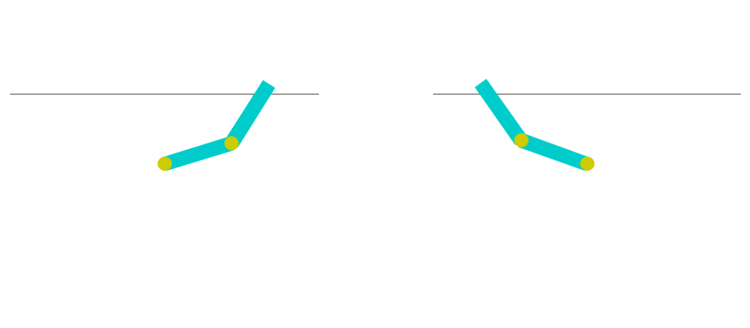

In [22]:
visualize_policy(Q_SARSA, episodes=2)

In [ ]:
visualize_policy(Q_QLearning, episodes=2)

In [ ]:
visualize_policy(Q_eta_Reward, episodes=2)